In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
data = pd.read_csv("eda_dataset.csv")

In [7]:
data.columns

Index(['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year', 'Month',
       'Day', 'Hour', 'Minute'],
      dtype='object')

In [8]:
data = data.drop(columns=['Minute'])

In [9]:
data['Datetime'] = pd.to_datetime(data[['Year', 'Month', 'Day', 'Hour']])

In [10]:
data.columns

Index(['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year', 'Month',
       'Day', 'Hour', 'Datetime'],
      dtype='object')

In [11]:
data['AQI_logged'] = np.log(data['AQI'])

In [12]:
data.head

<bound method NDFrame.head of         City  PM2.5   PM10    NO    NO2    NOx    NH3    CO    SO2      O3  \
0          0  80.47  84.90  1.42  21.90  20.65  22.83  1.42  32.26   46.71   
1          0  87.80  84.90  2.03  19.87  22.22  22.83  2.03  78.95   21.88   
2          0  90.53  84.90  1.72  20.11  22.12  22.83  1.72  95.86   67.67   
3          0  83.53  84.90  0.75  16.35  16.48  22.83  0.75  44.91   88.92   
4          0  68.40  84.90  0.58  13.73  12.50  22.83  0.58  34.57  116.75   
...      ...    ...    ...   ...    ...    ...    ...   ...    ...     ...   
578790    25   9.50  36.00  2.75  25.57  15.85   4.57  0.62   1.85   27.75   
578791    25  17.25  49.25  3.62  33.20  20.62   3.78  0.76   2.02   25.58   
578792    25  36.00  71.00  2.20  30.80  18.20   3.67  0.58   1.77   26.15   
578793    25  15.75  63.00  1.02  28.90  16.00   3.80  0.49   0.75   15.82   
578794    25  15.00  66.00  0.40  26.85  14.05   5.20  0.59   2.10   17.05   

        ...  Toluene  Xylene    A

In [13]:
data = data.drop(columns=['AQI_Bucket'])

In [14]:
data

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Year,Month,Day,Hour,Datetime,AQI_logged
0,0,80.47,84.90,1.42,21.90,20.65,22.83,1.42,32.26,46.71,0.0,0.0,2.07,288.0,2015,1,29,9,2015-01-29 09:00:00,5.662960
1,0,87.80,84.90,2.03,19.87,22.22,22.83,2.03,78.95,21.88,0.0,0.0,2.13,181.0,2015,1,29,10,2015-01-29 10:00:00,5.198497
2,0,90.53,84.90,1.72,20.11,22.12,22.83,1.72,95.86,67.67,0.0,0.0,3.45,182.0,2015,1,29,11,2015-01-29 11:00:00,5.204007
3,0,83.53,84.90,0.75,16.35,16.48,22.83,0.75,44.91,88.92,0.0,0.0,3.25,182.0,2015,1,29,12,2015-01-29 12:00:00,5.204007
4,0,68.40,84.90,0.58,13.73,12.50,22.83,0.58,34.57,116.75,0.0,0.0,2.85,179.0,2015,1,29,13,2015-01-29 13:00:00,5.187386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578790,25,9.50,36.00,2.75,25.57,15.85,4.57,0.62,1.85,27.75,0.0,0.0,0.00,51.0,2020,6,30,20,2020-06-30 20:00:00,3.931826
578791,25,17.25,49.25,3.62,33.20,20.62,3.78,0.76,2.02,25.58,0.0,0.0,0.00,51.0,2020,6,30,21,2020-06-30 21:00:00,3.931826
578792,25,36.00,71.00,2.20,30.80,18.20,3.67,0.58,1.77,26.15,0.0,0.0,0.00,50.0,2020,6,30,22,2020-06-30 22:00:00,3.912023
578793,25,15.75,63.00,1.02,28.90,16.00,3.80,0.49,0.75,15.82,0.0,0.0,0.00,50.0,2020,6,30,23,2020-06-30 23:00:00,3.912023


In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [17]:
data = data.sort_index()

In [18]:
result = seasonal_decompose(data['AQI_logged'], model='additive', period=24)

<Figure size 1200x800 with 0 Axes>

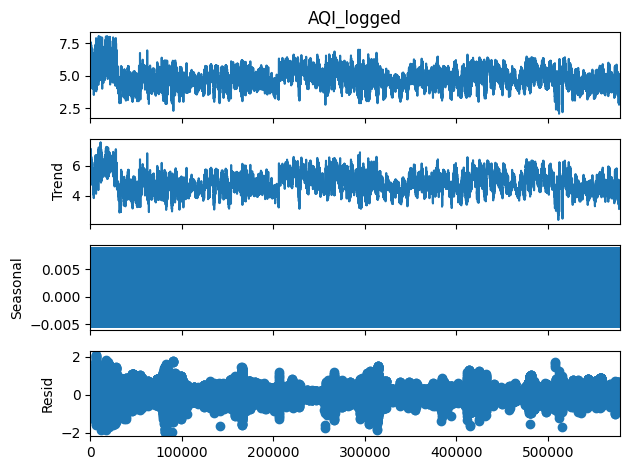

In [19]:
plt.figure(figsize=(12, 8))
result.plot()
plt.show()

In [16]:
temp = data["AQI_logged"]

In [17]:
def data_to_X_y(df, window_size=24):
  data_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(data_as_np)-window_size):
    row = [[a] for a in data_as_np[i:i+window_size]]
    X.append(row)
    label = data_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

In [18]:
WINDOW_SIZE = 24
X1, y1 = data_to_X_y(temp, WINDOW_SIZE)

In [19]:
split_index = data[data['Year'] == 2020].index[0]
print("The year 2020 starts at index:", split_index)

The year 2020 starts at index: 26914


In [20]:
X1.shape, y1.shape

((578771, 24, 1), (578771,))

In [21]:
X_train1, y_train1 = X1[:400000], y1[:400000]
X_val1, y_val1 = X1[400000:450000], y1[400000:450000]
X_test1, y_test1 = X1[450000:], y1[450000:]
X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((400000, 24, 1),
 (400000,),
 (50000, 24, 1),
 (50000,),
 (128771, 24, 1),
 (128771,))

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [29]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [30]:
model1 = Sequential()
model1.add(InputLayer((24, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [33]:
cp1 = ModelCheckpoint('model1/model.keras', save_best_only=True)
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp1])

Epoch 1/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - loss: 0.0110 - root_mean_squared_error: 0.1049 - val_loss: 0.0069 - val_root_mean_squared_error: 0.0831
Epoch 2/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - loss: 0.0109 - root_mean_squared_error: 0.1043 - val_loss: 0.0067 - val_root_mean_squared_error: 0.0816
Epoch 3/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 74s 6ms/step - loss: 0.0108 - root_mean_squared_error: 0.1040 - val_loss: 0.0068 - val_root_mean_squared_error: 0.0825
Epoch 4/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 75s 6ms/step - loss: 0.0107 - root_mean_squared_error: 0.1036 - val_loss: 0.0067 - val_root_mean_squared_error: 0.0816
Epoch 5/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 137s 11ms/step - loss: 0.0106 - root_mean_squared_error: 0.1032 - val_loss: 0.0065 - val_root_mean_squared_error: 0.0809
Epoch 6/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 138s 11ms/step - loss: 0.0106 - root_mean_squared_error: 0.1028 - val_loss: 0.0066 - val_root_mean_squared_error: 0.0813
Epoch 7/10
12500/1

In [34]:
from tensorflow.keras.models import load_model
model1 = load_model('model1/model.keras')

In [35]:
test_predictions = model1.predict(X_test1).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1})

4025/4025 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step


In [46]:
train_predictions = model1.predict(X_train1).flatten()
train_results = pd.DataFrame(data={'train Predictions':train_predictions, 'Actuals_train':y_train1})

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step


In [47]:
train_results.head()

,train Predictions,Actuals_train
0,5.062309,5.075174
1,5.062105,5.068904
2,5.062295,5.068904
3,5.067647,5.293305
4,5.331610,5.293305


In [36]:
test_results.head()

,Test Predictions,Actuals
0,4.568629,4.543295
1,4.545061,4.564348
2,4.569417,4.564348
3,4.568942,4.553877
4,4.557298,4.543295


In [38]:
# Look at the first hour of history for the first data sample
print(X_train1[0, 0, :])

[5.66296048]


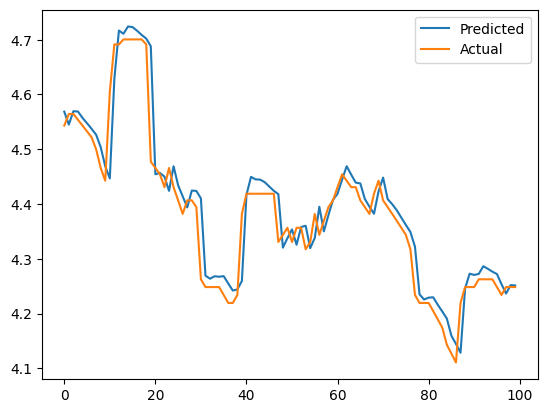

In [39]:
plt.plot(test_results['Test Predictions'][:100])
plt.plot(test_results['Actuals'][:100])
plt.legend(["Predicted","Actual"])

In [40]:
from sklearn.metrics import root_mean_squared_error, r2_score

In [41]:
root_mean_squared_error(test_predictions, y_test1), r2_score(test_predictions, y_test1)

(0.07377649082414389, 0.9871777462304259)

In [48]:
root_mean_squared_error(train_predictions, y_train1), r2_score(train_predictions, y_train1)

(0.1013637089189605, 0.9782311466710086)

In [49]:
import pandas as pd

prophet_data = pd.DataFrame()

prophet_data['ds'] = data.index  

prophet_data['y'] = data['AQI_logged'].values

In [50]:
prophet_data.to_csv('prophet_aqi_data.csv', index=False)

print("Dataframe successfully saved as 'prophet_aqi_data.csv'!")

Dataframe successfully saved as 'prophet_aqi_data.csv'!


In [22]:
X_train1.shape

(400000, 24, 1)

In [26]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

for exp in mlflow.search_experiments():
    print("ID:", exp.experiment_id, "| Name:", exp.name)

ID: 1 | Name: AQI_LSTM_Project
ID: 0 | Name: Default


In [28]:
data.columns

Index(['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'Year', 'Month', 'Day', 'Hour',
       'Datetime', 'AQI_logged'],
      dtype='object')